In [95]:
import gzip
import os
import shutil
import tempfile
import urllib.request
import pandas as pd
import anndata as ad
import decoupler as dc
import numpy as np
import omnipath as op
import networkx as nx
# https://corneto.org
import corneto as cn

In [96]:
##################################################################

df1 = pd.read_csv("/Users/botascan/Desktop/corneto/IFNGR1_IFNG_pathway_DE_results.csv")
df2 = pd.read_csv("/Users/botascan/Desktop/corneto/INSR_INS_pathway_DE_results.csv")
df3 = pd.read_csv("/Users/botascan/Desktop/corneto/STAT1_IFNB_pathway_DE_results.csv")
df4 = pd.read_csv("/Users/botascan/Desktop/corneto/TGFBR2_TGFB1_pathway_DE_results.csv")
df5 = pd.read_csv("/Users/botascan/Desktop/corneto/TNFRSF1A_TNFA_pathway_DE_results.csv")

df1 = df1.set_index('gene_ID').rename_axis(None).dropna()
df2 = df2.set_index('gene_ID').rename_axis(None).dropna()
df3 = df3.set_index('gene_ID').rename_axis(None).dropna()
df4 = df4.set_index('gene_ID').rename_axis(None).dropna()
df5 = df5.set_index('gene_ID').rename_axis(None).dropna()


receptors = ["IFNGR1", "INSR", "STAT1", "TGFBR2", "TNFRSF1A"]
cell_types = ['A549', 'BXPC3', 'HAP1', 'HT29', 'K562', 'MCF7']

# if single sample
# receptor = receptors[0] # choose receptor
# cell_type = cell_types[0] # choose cell type

# all transcription-factor data
collectri = dc.op.collectri(organism="human")
collectri

,source,target,weight,resources,references,sign_decision
0,MYC,TERT,1.0,DoRothEA-A;ExTRI;HTRI;NTNU.Curated;Pavlidis202...,10022128;10491298;10606235;10637317;10723141;1...,PMID
1,SPI1,BGLAP,1.0,ExTRI,10022617,default activation
2,SMAD3,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
3,SMAD4,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
4,STAT5A,IL2,1.0,ExTRI,10022878;11435608;17182565;17911616;22854263;2...,default activation
...,...,...,...,...,...,...
42985,NFKB,hsa-miR-143-3p,1.0,ExTRI,19472311,default activation
42986,AP1,hsa-miR-206,1.0,ExTRI;GEREDB;NTNU.Curated,19721712,PMID
42987,NFKB,hsa-miR-21,1.0,ExTRI,20813833;22387281,default activation
42988,NFKB,hsa-miR-224-5p,1.0,ExTRI,23474441;23988648,default activation


In [97]:
if (df1.dropna().equals(df1)):
    print("HEllo")

HEllo


In [98]:
# Identify the log2FC and p-value columns for these cells
log2_cols = [f'log2FC_{ct}' for ct in cell_types]
p_cols    = [f'p_cell_type{ct}' for ct in cell_types]

#df1[log2_cols]
#df1[p_cols]

# only log2FC values
debloated_df = df1[log2_cols]
data = debloated_df.T
data

,STAT1,WARS,PARP14,RNF213,IRF1,LAP3,PARP9,NLRC5,TAP2,B2M,...,KRI1,SSBP1,CCNT1,MAU2,ZNF148,MAP7D1,SEM1,MED17,RSL24D1,PAFAH1B1
log2FC_A549,-0.826928,-1.475619,-1.095130,-1.272662,-1.501644,-1.432542,-0.782295,-0.864590,-1.117488,-1.555413,...,-0.143179,-0.113792,-0.146925,-0.157851,-0.004653,-0.151044,-0.120629,-0.169614,-0.091171,-0.012802
log2FC_BXPC3,-1.167024,-1.742651,-1.326912,-1.240130,-1.480489,-1.267982,-1.145450,-1.529261,-1.302192,-0.928855,...,-0.029306,-0.033736,0.109830,-0.206006,-0.138523,-0.072461,0.016006,0.156762,0.022208,0.011551
log2FC_HAP1,-1.315314,-1.283305,-1.431360,-0.870919,-1.414034,-1.351792,-1.436759,-1.471867,-1.348161,-1.293354,...,-0.116754,0.016454,-0.070673,-0.042991,-0.001863,0.050319,-0.120346,-0.149173,0.213855,-0.013027
log2FC_HT29,-1.217859,-1.537470,-1.247932,-1.315691,-1.409362,-1.258586,-1.231235,-1.379454,-1.261662,-1.193032,...,0.141246,-0.076945,-0.023646,-0.121607,0.026214,-0.152742,0.006064,0.090769,0.165056,-0.068308
log2FC_K562,-1.611977,-1.106555,-1.200858,-0.201141,-1.856694,-0.546498,-1.670941,-1.650919,-1.610164,-1.216249,...,0.037134,-0.002537,-0.064474,-0.025292,0.103373,0.029216,-0.081957,-0.097500,-0.139091,-0.090887
log2FC_MCF7,-1.420898,-1.531302,-1.537843,-0.683001,-1.462251,-0.542226,-1.403774,-1.654170,-1.741662,-1.373184,...,0.009549,0.043170,0.117075,0.048596,0.038466,0.056014,0.028091,-0.054294,0.103837,0.039953


In [99]:
# calculatae activity score and significance
tf_acts, tf_p = dc.mt.ulm(data=data, net=collectri)

# filter out by p value
msk = (tf_p.T < 0.05).iloc[:,0]
tf_p = tf_p.loc[:,msk]

tf_acts.T.to_csv(f"TF_act_scores_")
#tf_p.T.to_csv(f"TF_p_{receptor}_{cell_type}")

In [100]:
# CORNETO / CARNIVAL
from corneto.methods.future import CarnivalFlow

# PKN, all gene network data
pkn = op.interactions.OmniPath.get(databases=["SIGNOR"], genesymbols=True)
pkn = pkn[pkn.consensus_direction == True]

pkn["interaction"] = pkn["is_stimulation"].astype(int) - pkn["is_inhibition"].astype(int)
sel_pkn = pkn[["source_genesymbol", "interaction", "target_genesymbol"]]

In [101]:
from corneto.io import load_graph_from_sif_tuples

G = load_graph_from_sif_tuples([(r[0], r[1], r[2]) for _,r in sel_pkn.iterrows() if r[1] != 0])

significant_tfs = tf_acts[tf_p <= 0.001].T.dropna().sort_values(by=f"log2FC_A549", ascending=False)

measurements = significant_tfs.loc[significant_tfs.index.intersection(G.V)].to_dict()[f"log2FC_A549"]

inputs = {"IFNGR1" : 1}

/var/folders/c2/zy0c1sg140qdkfyn2x4n9tq40000gn/T/ipykernel_7920/837011583.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  G = load_graph_from_sif_tuples([(r[0], r[1], r[2]) for _,r in sel_pkn.iterrows() if r[1] != 0])


In [102]:
# create dataset
carnival_data = dict()
for inp, v in inputs.items():
    carnival_data[inp] = dict(value=v, role="input", mapping="vertex")

for out, v in measurements.items():
    carnival_data[out] = dict(value=v, role="output", mapping="vertex")

data = cn.Data.from_cdict({"sample1": carnival_data})
data

Data(n_samples=1, n_feats=[9])

In [103]:
# use CARNIVAL
carnival = CarnivalFlow(lambda_reg=1.0, indirect_rule_penalty=10)
P = carnival.build(G, data)
P.expr
P.solve(solver="gurobi", max_seconds=60, verbosity=1)

for o in P.objectives:
    print(o.name, "->", o.value)

(CVXPY) Nov 10 01:05:06 PM: Your problem has 10230 variables, 29371 constraints, and 1 parameters.
(CVXPY) Nov 10 01:05:06 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Nov 10 01:05:06 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Nov 10 01:05:06 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Nov 10 01:05:06 PM: Compiling problem (target solver=GUROBI).
(CVXPY) Nov 10 01:05:06 PM: Reduction chain: CvxAttr2Constr -> Qp2SymbolicQp -> QpMatrixStuffing -> GUROBI
(CVXPY) Nov 10 01:05:06 PM: Applying reduction CvxAttr2Constr
(CVXPY) Nov 10 01:05:06 PM: Applying reduction Qp2SymbolicQp
(CVXPY) Nov 10 01:05:06 PM: Applying reduction QpMatrixStuffing
(CVXPY) Nov 10 01:05:06 PM: Applying reduction GUROBI
(CVXPY) Nov 10 01:05:06 PM: Finished problem compilation (took 1.043e-01 seconds).
(CVXPY) Nov 10 01:05:06 PM: (Subsequent compilations of this problem, using the same arguments, 

Unreachable vertices for sample: 0
                                     CVXPY                                     
                                     v1.6.6                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
Set parameter OutputFlag to value 1


2025-11-10 13:05:06 | [INFO] Set parameter OutputFlag to value 1


Set parameter QCPDual to value 1


2025-11-10 13:05:06 | [INFO] Set parameter QCPDual to value 1


...

Optimal solution found (tolerance 1.00e-04)


2025-11-10 13:05:07 | [INFO] Optimal solution found (tolerance 1.00e-04)


Best objective -1.318279373047e+01, best bound -1.318279373047e+01, gap 0.0000%


2025-11-10 13:05:07 | [INFO] Best objective -1.318279373047e+01, best bound -1.318279373047e+01, gap 0.0000%
(CVXPY) Nov 10 01:05:07 PM: Problem status: optimal
(CVXPY) Nov 10 01:05:07 PM: Optimal value: 2.869e+01
(CVXPY) Nov 10 01:05:07 PM: Compilation took 1.043e-01 seconds
(CVXPY) Nov 10 01:05:07 PM: Solver (including time spent in interface) took 9.136e-01 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
error_sample1_0 -> 13.689724106686342
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 15.0


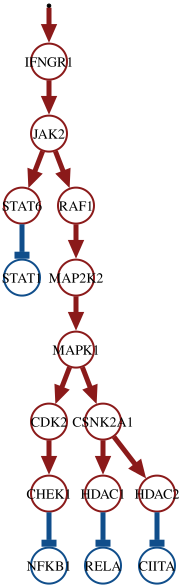

In [104]:
# extract edges
sol_edges = np.flatnonzero(np.abs(P.expr.edge_value.value) > 0.5)
carnival.processed_graph.plot_values(
    vertex_values=P.expr.vertex_value.value,
    edge_values=P.expr.edge_value.value,
    edge_indexes=sol_edges
)

# extract solution Graph
#G_sol = carnival.processed_graph.edge_subgraph(sol_edges)
#G_sol.plot()